# Decision Tree Model Training and Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

df = pd.read_csv("adult_preprocessed.csv")

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Train Decision Tree

In [2]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [8]:
model


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Evaluation Metrics

In [3]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.8520282728948986

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      4940
           1       0.79      0.52      0.63      1568

    accuracy                           0.85      6508
   macro avg       0.83      0.74      0.77      6508
weighted avg       0.85      0.85      0.84      6508



## Confusion Matrix

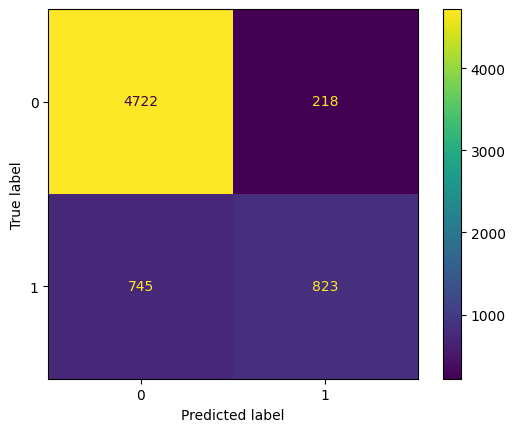

In [4]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## ROC Curve

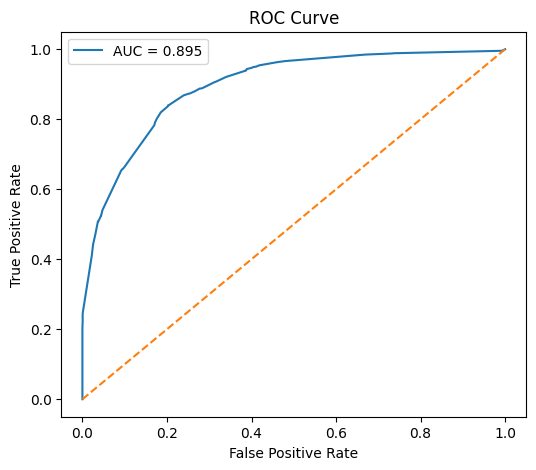

In [5]:
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Feature Importance

relationship      0.408169
education.num     0.219064
capital.gain      0.211058
capital.loss      0.062932
age               0.041447
hours.per.week    0.036052
occupation        0.007437
workclass         0.004885
education         0.003630
fnlwgt            0.003555
native.country    0.000834
marital.status    0.000713
race              0.000223
sex               0.000000
dtype: float64


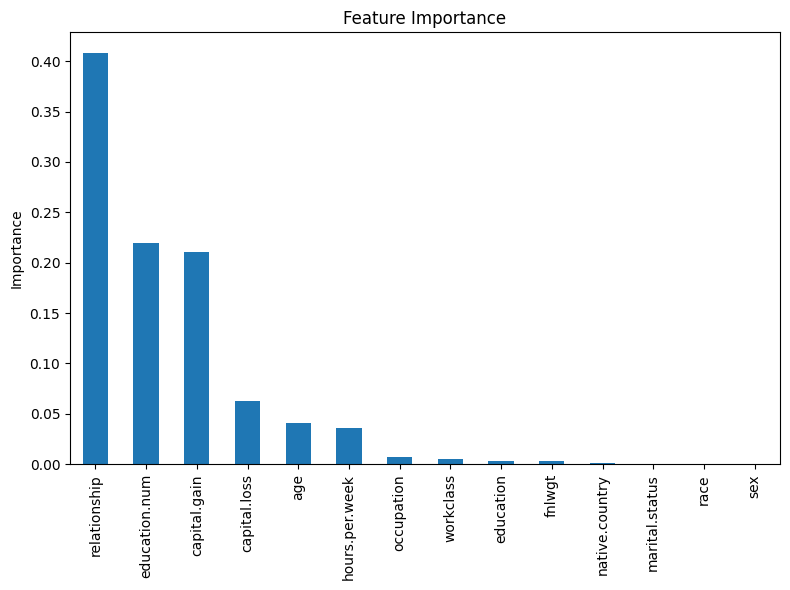

In [6]:
importance = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

print(importance)

plt.figure(figsize=(8,6))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## Decision Tree Visualization

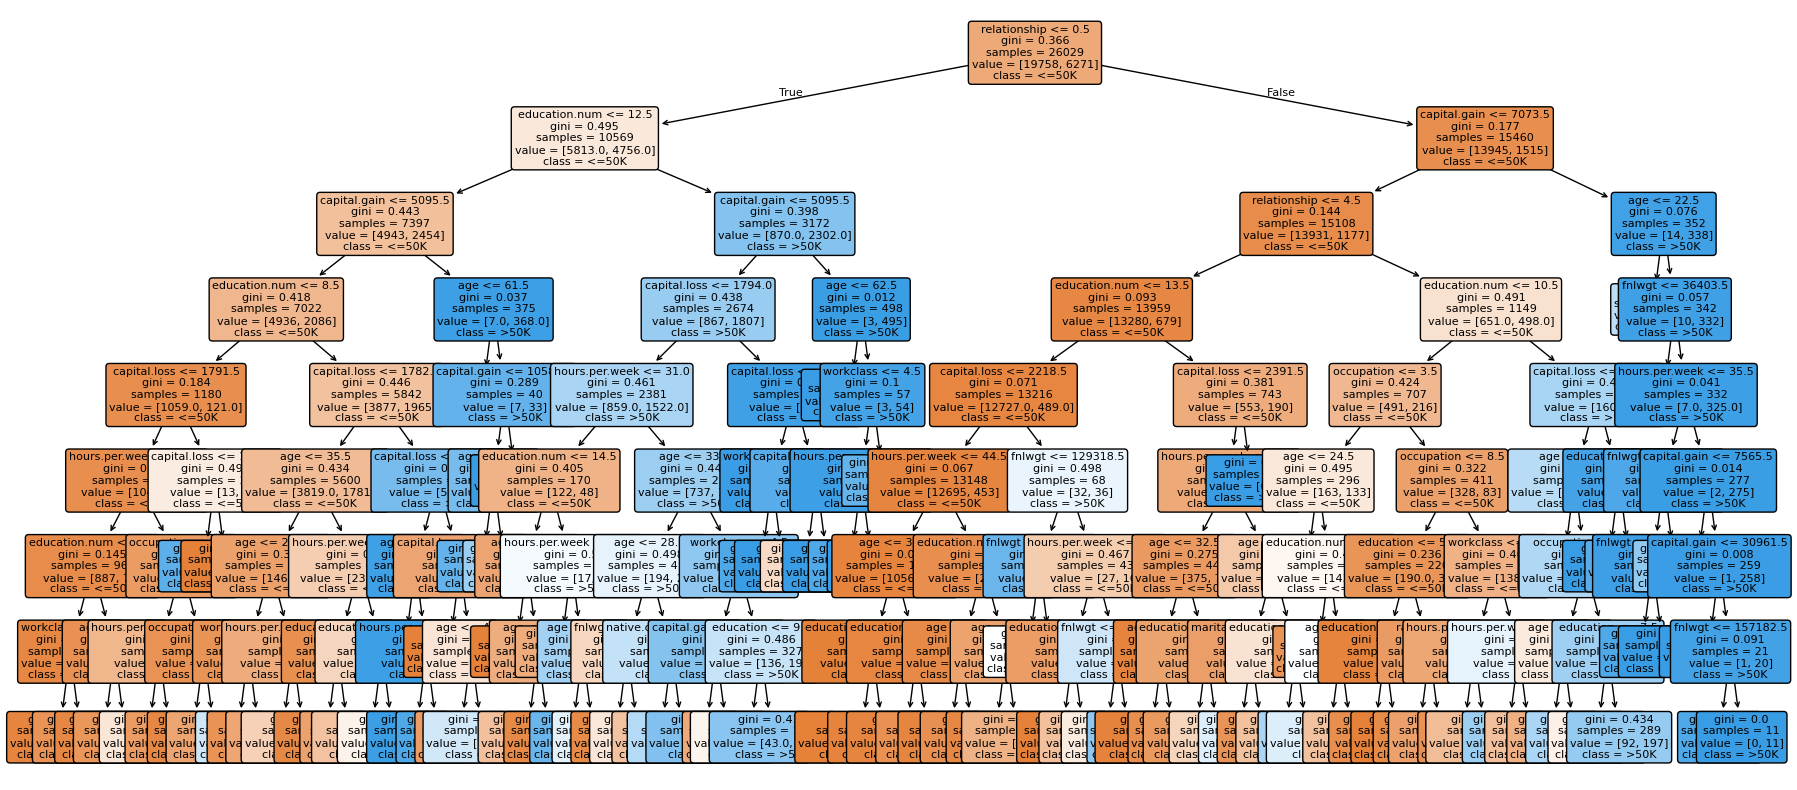

In [ ]:
plt.figure(figsize=(22,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()
